In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score


In [47]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['Species'] = iris.target

In [48]:
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
62,6.0,2.2,4.0,1.0,1
46,5.1,3.8,1.6,0.2,0
140,6.7,3.1,5.6,2.4,2
4,5.0,3.6,1.4,0.2,0
95,5.7,3.0,4.2,1.2,1


In [49]:
df = df[df['Species'] != 0][['sepal width (cm)', 'petal length (cm)', 'Species']]

In [50]:
df.head()

,sepal width (cm),petal length (cm),Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


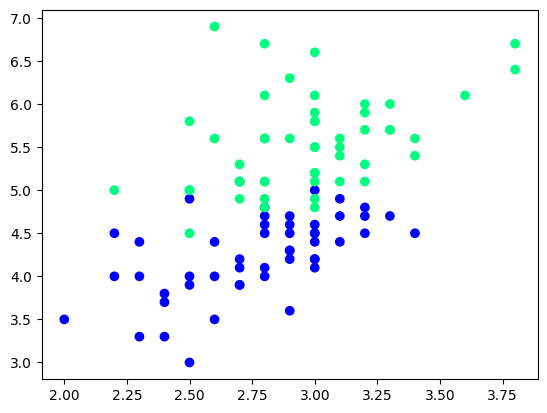

In [51]:
plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c = df['Species'], cmap="winter")

In [52]:
df = df.sample(100)
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [53]:
df_train

,sepal width (cm),petal length (cm),Species
78,2.9,4.5,1
61,3.0,4.2,1
96,2.9,4.2,1
85,3.4,4.5,1
143,3.2,5.9,2
80,2.4,3.8,1
69,2.5,3.9,1
133,2.8,5.1,2
91,3.0,4.6,1
139,3.1,5.4,2


In [54]:
df_val

,sepal width (cm),petal length (cm),Species
56,3.3,4.7,1
53,2.3,4.0,1
144,3.3,5.7,2
59,2.7,3.9,1
116,3.0,5.5,2


In [55]:
df_test

,sepal width (cm),petal length (cm),Species
81,2.4,3.7,1
138,3.0,4.8,2
146,2.5,5.0,2
101,2.7,5.1,2
140,3.1,5.6,2


In [56]:
X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

In [57]:
X_test

array([[3.3, 4.7],
       [2.3, 4. ],
       [3.3, 5.7],
       [2.7, 3.9],
       [3. , 5.5]])

## Case1: Bagging

In [58]:
# data for tree 1
df_bag = df_train.sample(8, replace = True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

In [59]:
df_bag

,sepal width (cm),petal length (cm),Species
78,2.9,4.5,1
61,3.0,4.2,1
61,3.0,4.2,1
61,3.0,4.2,1
69,2.5,3.9,1
80,2.4,3.8,1
96,2.9,4.2,1
78,2.9,4.5,1


In [60]:
dt_bag1 = DecisionTreeClassifier()

In [61]:
def evaluate(clf, X, y):
    clf.fit(X, y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf = clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

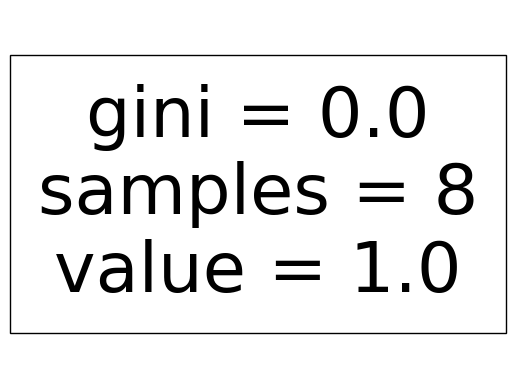

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


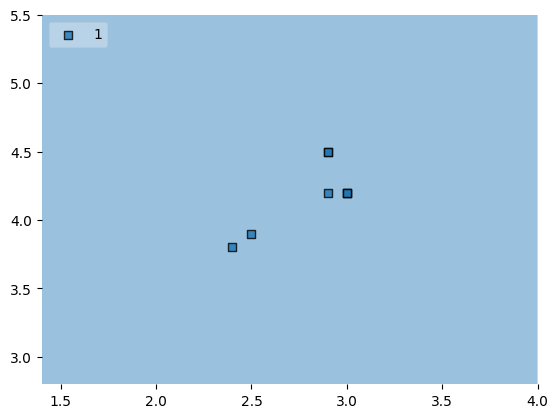

In [62]:
evaluate(dt_bag1, X, y)

In [63]:
# data for tree 12
df_bag = df_train.sample(8, replace = True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal width (cm),petal length (cm),Species
69,2.5,3.9,1
91,3.0,4.6,1
96,2.9,4.2,1
69,2.5,3.9,1
69,2.5,3.9,1
85,3.4,4.5,1
69,2.5,3.9,1
80,2.4,3.8,1


In [64]:
dt_bag2 = DecisionTreeClassifier()

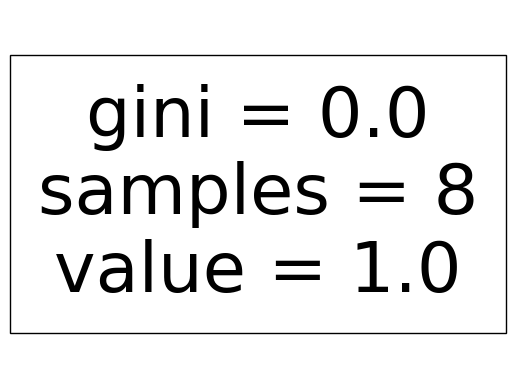

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


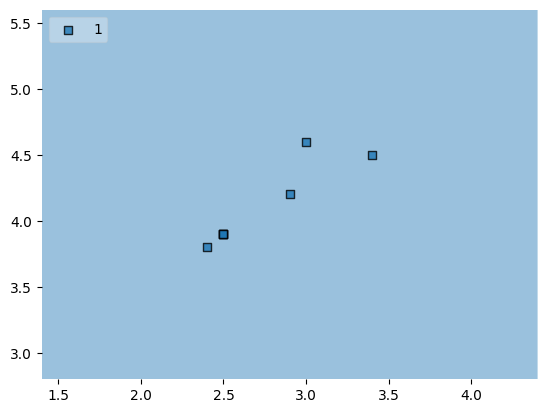

In [65]:
evaluate(dt_bag2, X, y)

In [66]:
# data for tree 3
df_bag = df_train.sample(8, replace = True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal width (cm),petal length (cm),Species
139,3.1,5.4,2
69,2.5,3.9,1
96,2.9,4.2,1
78,2.9,4.5,1
139,3.1,5.4,2
61,3.0,4.2,1
78,2.9,4.5,1
139,3.1,5.4,2


In [67]:
dt_bag3 = DecisionTreeClassifier()

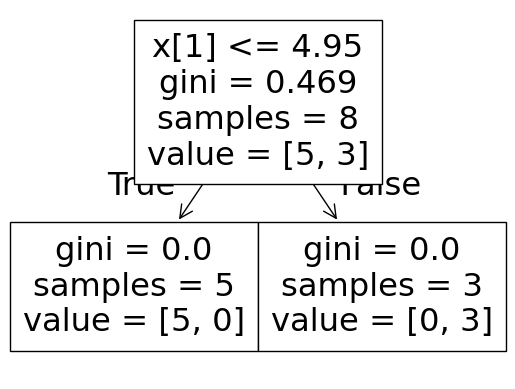

E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


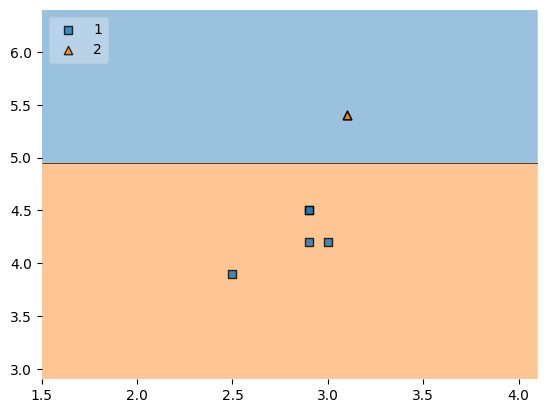

In [68]:
evaluate(dt_bag3, X, y)

In [69]:
df_test

,sepal width (cm),petal length (cm),Species
81,2.4,3.7,1
138,3.0,4.8,2
146,2.5,5.0,2
101,2.7,5.1,2
140,3.1,5.6,2


In [72]:
print("Predictor 1:", dt_bag1.predict(np.array([2.7, 5.1]).reshape(1, 2)))
print("Predictor 2:", dt_bag2.predict(np.array([2.7, 5.1]).reshape(1, 2)))
print("Predictor 3:", dt_bag3.predict(np.array([2.7, 5.1]).reshape(1, 2)))

Predictor 1: [1]
Predictor 2: [1]
Predictor 3: [2]


E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Application\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting

In [73]:
# Row sampling without replacement
df_train

,sepal width (cm),petal length (cm),Species
78,2.9,4.5,1
61,3.0,4.2,1
96,2.9,4.2,1
85,3.4,4.5,1
143,3.2,5.9,2
80,2.4,3.8,1
69,2.5,3.9,1
133,2.8,5.1,2
91,3.0,4.6,1
139,3.1,5.4,2


In [74]:
df_train.sample(8)

,sepal width (cm),petal length (cm),Species
78,2.9,4.5,1
133,2.8,5.1,2
143,3.2,5.9,2
139,3.1,5.4,2
61,3.0,4.2,1
91,3.0,4.6,1
85,3.4,4.5,1
80,2.4,3.8,1


## Random subspaces

In [ ]:
# Column sampling with replacements
df.sample(3, replace=True, axis=1)

,Species,sepal width (cm),sepal width (cm)
141,2,3.1,3.1
93,1,2.3,2.3
102,2,3.0,3.0
96,1,2.9,2.9
74,1,2.9,2.9
...,...,...,...
70,1,3.2,3.2
120,2,3.2,3.2
98,1,2.5,2.5
57,1,2.4,2.4


## Random Patches

In [90]:
# Both row and column sampling with replacements
df.sample(5, replace=True).sample(2, replace=True, axis=1)

,petal length (cm),Species
109,6.1,2
101,5.1,2
109,6.1,2
106,4.5,2
103,5.6,2
